**24BAD128**\
**EXP 9 – SCENARIO 1 (User-Based Collaborative Filtering using KNN)**

**Explanation:**
1. The program loads the MovieLens dataset (ratings and movies).
2. Dataset structure and missing values are checked.
3. Ratings and movie datasets are merged using movieId.
4. A User-Item matrix is created with users as rows and movies as columns.
5. Missing values in the matrix are filled with 0.

**Features Used:**
1. User ID
2. Movie Title
3. Ratings

**Steps Performed:**
1. User-Item matrix is normalized by filling missing values.
2. Cosine similarity is computed between users.
3. Top 5 similar users are identified.
4. Ratings are predicted using weighted average of similar users.
5. Top-N recommended movies are generated for a user.

**Evaluation:**
  1. RMSE (Root Mean Square Error)
  2. MAE (Mean Absolute Error)
  3. Matrix sparsity is calculated

**Visualizations:**
1. User-Item Matrix Heatmap → shows rating distribution
2. User Similarity Matrix → shows similarity between users
3. Bar Chart → shows top recommended movies

24BAD128-EXP 9 Scenario 1
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  


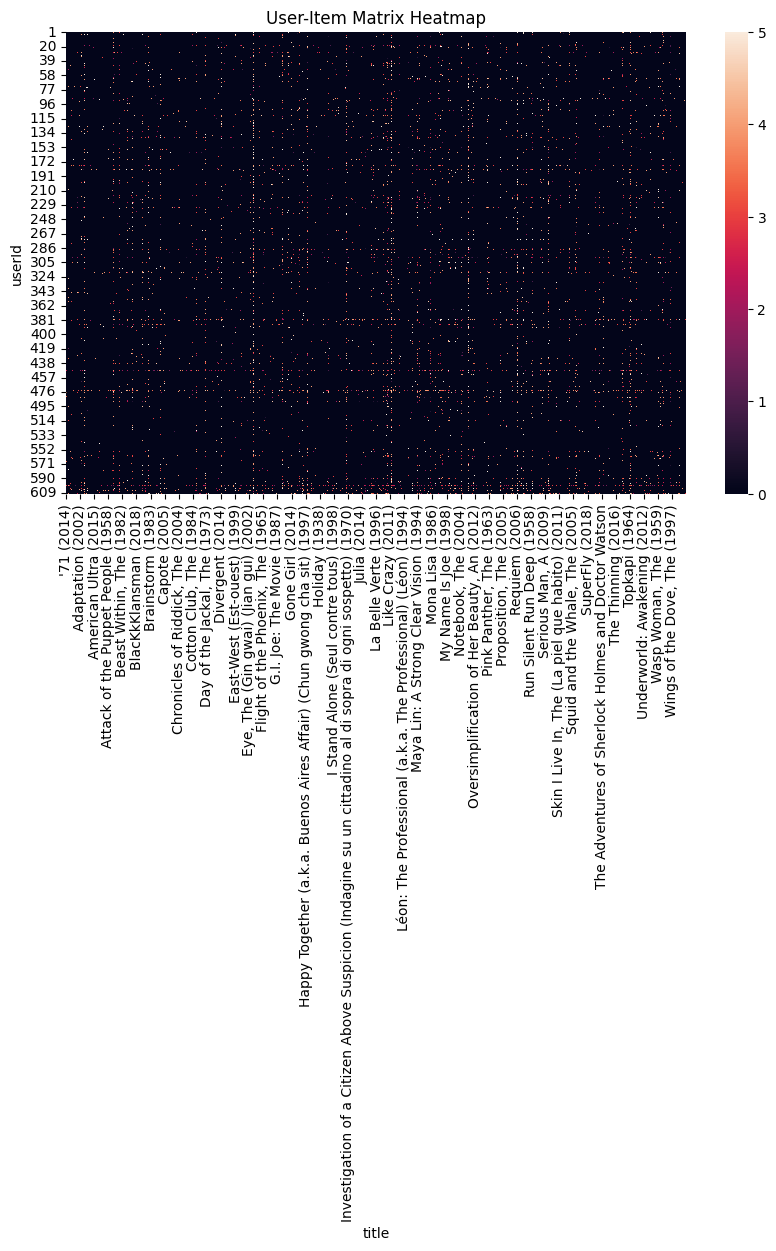

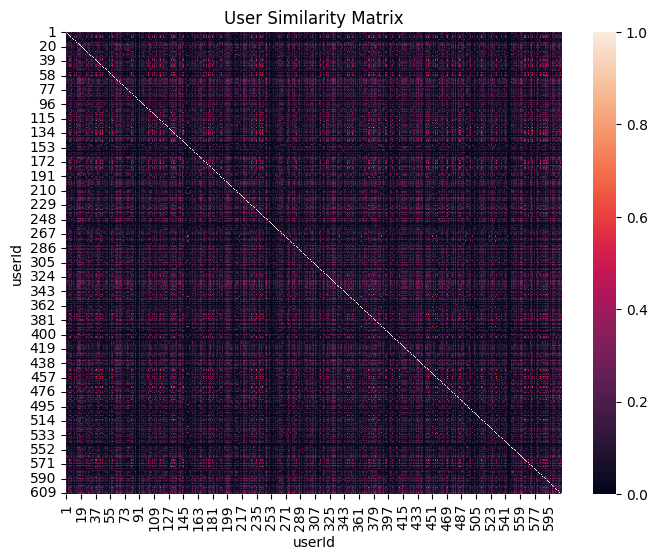

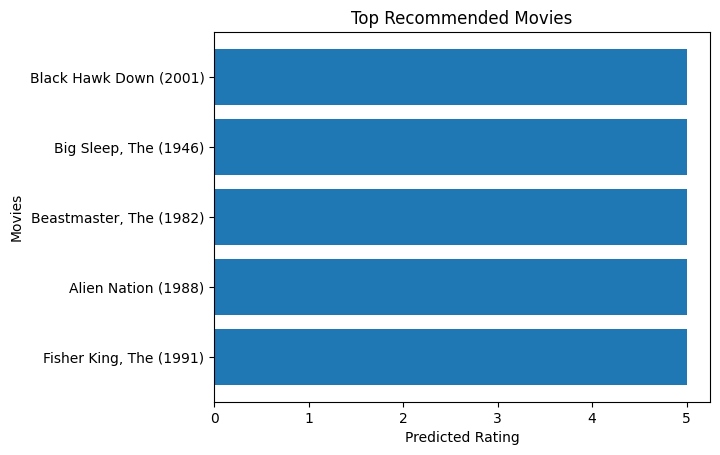

In [2]:
#from google.colab import files
#uploaded=files.upload()

#24BAD128-EXP 9 Scenario 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

print("24BAD128-EXP 9 Scenario 1")
ratings = pd.read_csv(r"ratings.csv")
movies = pd.read_csv(r"movies.csv")

print(ratings.head())
print(movies.head())
print(ratings.info())

df = pd.merge(ratings, movies, on='movieId')

user_item_matrix = df.pivot_table(index='userId',
                                 columns='title',
                                 values='rating')

user_item_filled = user_item_matrix.fillna(0)

user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

def get_similar_users(user_id, n=5):
    return user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]

print("\nTop similar users for User 1:")
print(get_similar_users(1))

def predict_rating(user_id, movie):
    similar_users = get_similar_users(user_id, 5)
    num, den = 0, 0

    for sim_user, sim_score in similar_users.items():
        rating = user_item_matrix.loc[sim_user, movie]
        if not np.isnan(rating):
            num += sim_score * rating
            den += sim_score

    return num / den if den != 0 else 0

def recommend_movies(user_id, n=5):
    unseen_movies = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id].isna()].index

    predictions = {}
    for movie in unseen_movies:
        predictions[movie] = predict_rating(user_id, movie)

    return sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:n]

print("\nTop Recommendations for User 1:")
print(recommend_movies(1))

y_true, y_pred = [], []

for user in user_item_matrix.index:
    for movie in user_item_matrix.columns:
        if not np.isnan(user_item_matrix.loc[user, movie]):
            y_true.append(user_item_matrix.loc[user, movie])
            y_pred.append(predict_rating(user, movie))

rmse = sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("\nRMSE:", rmse)
print("MAE:", mae)

sparsity = 1.0 - (user_item_matrix.count().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))
print("\nMatrix Sparsity:", sparsity)

plt.figure(figsize=(10,6))
sns.heatmap(user_item_filled)
plt.title("User-Item Matrix Heatmap")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df)
plt.title("User Similarity Matrix")
plt.show()

rec = recommend_movies(1)
movies_list = [x[0] for x in rec]
scores = [x[1] for x in rec]

plt.figure()
plt.barh(movies_list, scores)
plt.title("Top Recommended Movies")
plt.xlabel("Predicted Rating")
plt.ylabel("Movies")
plt.show()


**24BAD128**\
**EXP 9 – SCENARIO 2 (Item-Based Collaborative Filtering)**

**Explanation:**
1. The program loads the MovieLens dataset (ratings data).
2. Dataset is filtered to include active users and popular movies.
3. An Item-User matrix is created with movies as rows and users as columns.
4. Missing values are filled with 0 for computation.
5. Item similarity is calculated using cosine similarity.

**Features Used:**
1. Movie ID
2. User ID
3. Ratings

**Steps Performed:**
1. Item-User matrix is created and preprocessed.
2. Cosine similarity is computed between items (movies).
3. Top similar items are identified for a given movie.
4. Recommendations are generated based on user’s past rated items.
5. Scores are calculated using similarity × user rating.
6. Top-N recommended items are returned.

**Evaluation:**
1. RMSE (Root Mean Square Error)
2. Precision@K (relevance of top recommendations)

**Analysis:**
1. Item-based method is more stable than user-based filtering.
2. Popular items get more accurate recommendations.
3. Works well for large datasets (better scalability).

**Visualizations:**
1. Item Similarity Heatmap → shows similarity between movies.
2. Top Similar Items Graph → displays similar movies.
3. Recommendation Graph → shows recommended movies for a user.

24BAD128-EXP 9 Scenario 2
Dataset Loaded
   user_id  movie_id  rating
0        1         1     4.0
1        1         3     4.0
2        1         6     4.0
3        1        47     5.0
4        1        50     5.0
Filtered Data Shape: (25521, 3)
Item-User Matrix Shape: (626, 314)

Similar Movies to Movie 1:
movie_id
780     0.595711
480     0.586436
648     0.584033
588     0.555281
3114    0.550989
Name: 1, dtype: float64

Recommended Movies for User 1:
2918    22.946893
380     15.297550
318     13.763436
1968    12.606328
2683    11.958189
2081    11.499381
2355    10.267895
3210     9.790253
377      9.330897
1036     8.861869
dtype: float64

Not enough data for RMSE

Precision@5: 0.0


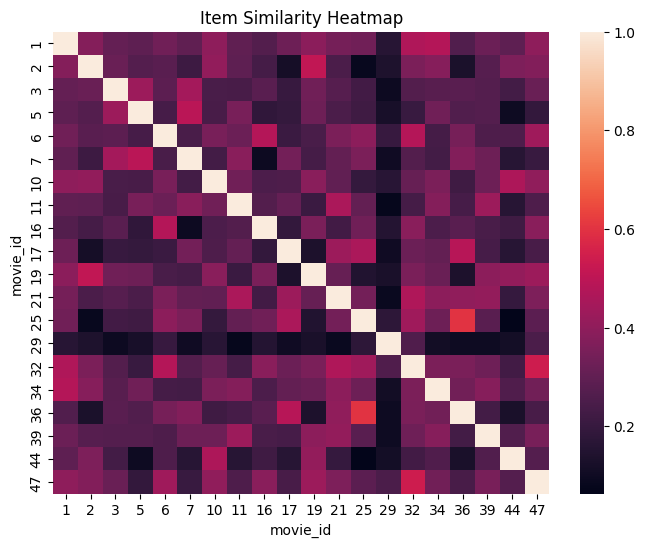

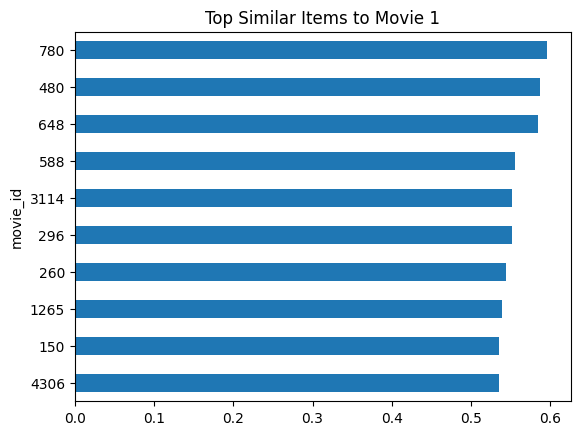

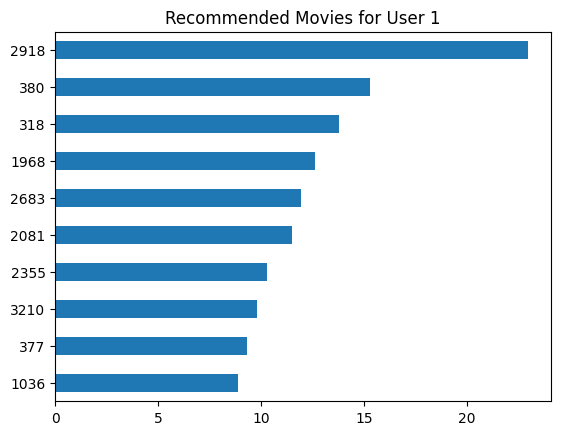

In [5]:
#from google.colab import files
#uploaded=files.upload()

#24BAD128-EXP 9 Scenario 2
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

print("24BAD128-EXP 9 Scenario 2")
ratings = pd.read_csv(
    r"ratings.csv",
    usecols=['userId', 'movieId', 'rating'],
    nrows=50000
)

ratings.rename(columns={
    'userId': 'user_id',
    'movieId': 'movie_id'
}, inplace=True)

print("Dataset Loaded")
print(ratings.head())

user_counts = ratings['user_id'].value_counts()
active_users = user_counts[user_counts > 20].index

movie_counts = ratings['movie_id'].value_counts()
popular_movies = movie_counts[movie_counts > 20].index

data = ratings[
    (ratings['user_id'].isin(active_users)) &
    (ratings['movie_id'].isin(popular_movies))
]

print("Filtered Data Shape:", data.shape)

item_user_matrix = data.pivot_table(
    index='movie_id',
    columns='user_id',
    values='rating'
)

print("Item-User Matrix Shape:", item_user_matrix.shape)

item_user_filled = item_user_matrix.fillna(0)

item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

def get_similar_items(movie_id, n=5):
    if movie_id not in item_similarity_df.index:
        return "Movie not found"

    similar_items = item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]
    return similar_items


print("\nSimilar Movies to Movie 1:")
print(get_similar_items(item_user_matrix.index[0]))

def recommend_items(user_id, n=10):
    if user_id not in item_user_matrix.columns:
        return "User not found"

    user_ratings = item_user_matrix[user_id].dropna()

    scores = pd.Series(dtype=float)

    for movie, rating in user_ratings.items():
        similar_items = get_similar_items(movie, n=5)

        for sim_movie, similarity in similar_items.items():
            if sim_movie not in user_ratings:
                scores[sim_movie] = scores.get(sim_movie, 0) + similarity * rating

    return scores.sort_values(ascending=False).head(n)

sample_user = item_user_matrix.columns[0]

print(f"\nRecommended Movies for User {sample_user}:")
print(recommend_items(sample_user))

actual = []
predicted = []

for user in item_user_matrix.columns[:50]:  # limit users
    recs = recommend_items(user, n=5)

    if isinstance(recs, pd.Series):
        for movie in recs.index:
            if movie in item_user_matrix.index:
                pred = recs[movie]
                actual_rating = item_user_matrix.loc[movie, user]

                if not np.isnan(actual_rating):
                    actual.append(actual_rating)
                    predicted.append(pred)

if len(actual) > 0:
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("\nRMSE:", rmse)
else:
    print("\nNot enough data for RMSE")

def precision_at_k(user_id, k=5):
    recommended = recommend_items(user_id, n=k)

    if not isinstance(recommended, pd.Series):
        return 0

    relevant = 0
    total = k

    for movie in recommended.index:
        if movie in item_user_matrix.index:
            if item_user_matrix.loc[movie, user_id] >= 3:  # relevant threshold
                relevant += 1

    return relevant / total


print("\nPrecision@5:", precision_at_k(sample_user))

plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Heatmap")
plt.show()

movie_id = item_user_matrix.index[0]
similar_items = get_similar_items(movie_id, n=10)

if isinstance(similar_items, pd.Series):
    similar_items.plot(kind='barh')
    plt.title(f"Top Similar Items to Movie {movie_id}")
    plt.gca().invert_yaxis()
    plt.show()

recs = recommend_items(sample_user)

if isinstance(recs, pd.Series):
    recs.plot(kind='barh')
    plt.title(f"Recommended Movies for User {sample_user}")
    plt.gca().invert_yaxis()
    plt.show()
